In [32]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harshrishi7/acndata/acndata_sessions.json.xlsx


In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
acn = pd.read_excel(
    '/kaggle/input/datasets/harshrishi7/acndata/acndata_sessions.json.xlsx'
)
acn.head()

,_meta,end,min_kWh,site,start,_items,_id,clusterID,connectionTime,disconnectTime,...,userID,userInputs,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID.1
0,NaN,NaN,NaN,caltech,NaN,NaN,5bc90cb9f9af8b0d7fe77cd2,39.0,"Wed, 25 Apr 2018 11:08:04 GMT","Wed, 25 Apr 2018 13:20:10 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd3,39.0,"Wed, 25 Apr 2018 13:45:10 GMT","Thu, 26 Apr 2018 00:56:16 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd4,39.0,"Wed, 25 Apr 2018 13:45:50 GMT","Wed, 25 Apr 2018 23:04:45 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd5,39.0,"Wed, 25 Apr 2018 14:37:06 GMT","Wed, 25 Apr 2018 23:55:34 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd6,39.0,"Wed, 25 Apr 2018 14:40:34 GMT","Wed, 25 Apr 2018 23:03:12 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
acn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16304 entries, 0 to 16303
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   _meta               0 non-null      float64
 1   end                 0 non-null      float64
 2   min_kWh             0 non-null      float64
 3   site                1 non-null      object 
 4   start               0 non-null      float64
 5   _items              0 non-null      float64
 6   _id                 14999 non-null  object 
 7   clusterID           14999 non-null  float64
 8   connectionTime      14999 non-null  object 
 9   disconnectTime      14999 non-null  object 
 10  doneChargingTime    14991 non-null  object 
 11  kWhDelivered        14999 non-null  float64
 12  sessionID           14999 non-null  object 
 13  siteID              14999 non-null  float64
 14  spaceID             14999 non-null  object 
 15  stationID           14999 non-null  object 
 16  time

In [36]:
acn['connectionTime'] = pd.to_datetime(
    acn['connectionTime']
)

acn['disconnectTime'] = pd.to_datetime(
    acn['disconnectTime']
)

acn['doneChargingTime'] = pd.to_datetime(
    acn['doneChargingTime']
)

In [37]:
acn['session_duration_hours'] = (
    (
        acn['disconnectTime']
        -
        acn['connectionTime']
    ).dt.total_seconds()
) / 3600

In [38]:
acn['charging_duration_hours'] = (
    (
        acn['doneChargingTime']
        -
        acn['connectionTime']
    ).dt.total_seconds()
) / 3600

In [39]:
acn['idle_time_hours'] = (
    acn['session_duration_hours']
    -
    acn['charging_duration_hours']
)
acn['idle_time_hours'] = acn[
    'idle_time_hours'
].clip(lower=0)

In [40]:
acn['baseline_price'] = 15

In [41]:
acn['baseline_revenue'] = (
    acn['kWhDelivered']
    *
    acn['baseline_price']
)

In [42]:
acn['session_utilization'] = np.where(
    acn['session_duration_hours'] > 0,

    acn['charging_duration_hours']
    /
    acn['session_duration_hours'],

    0
)

In [43]:
high_threshold = acn[
    'session_utilization'
].quantile(0.80)

low_threshold = acn[
    'session_utilization'
].quantile(0.30)

In [44]:
def dynamic_price(utilization):

    if utilization > high_threshold:
        return 20
    
    elif utilization < low_threshold:
        return 10
    
    else:
        return 15

In [45]:
acn['dynamic_price'] = acn[
    'session_utilization'
].apply(dynamic_price)

In [46]:
acn['dynamic_revenue'] = (
    acn['kWhDelivered']
    *
    acn['dynamic_price']
)

In [47]:
old_total = acn[
    'baseline_revenue'
].sum()

new_total = acn[
    'dynamic_revenue'
].sum()

revenue_gain = (
    (new_total - old_total)
    /
    old_total
) * 100

print("Old Revenue:", old_total)

print("New Revenue:", new_total)

print("Revenue Gain %:", revenue_gain)

Old Revenue: 2025419.748493453
New Revenue: 2084177.002396693
Revenue Gain %: 2.9009914585332135


In [48]:
acn['dynamic_price'].value_counts()

dynamic_price
15    8157
10    4889
20    3258
Name: count, dtype: int64

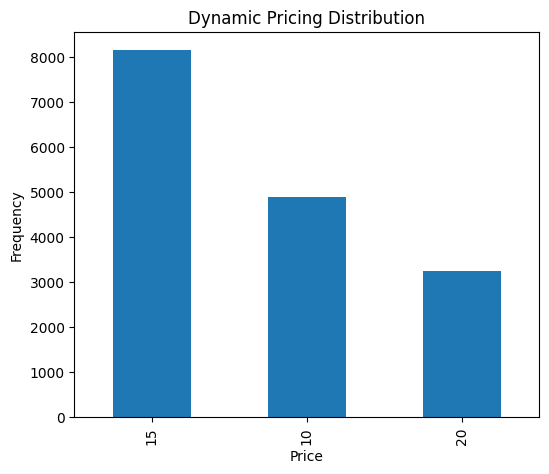

In [49]:
acn['dynamic_price'].value_counts().plot(
    kind='bar',
    figsize=(6,5)
)

plt.title('Dynamic Pricing Distribution')

plt.xlabel('Price')

plt.ylabel('Frequency')

plt.show()

In [50]:
discount_sessions = acn[
    acn['dynamic_price'] == 10
]

In [51]:
before_sessions = len(discount_sessions)

In [52]:
after_sessions = before_sessions * 1.25

assume 25% increase

In [53]:
response_rate = (
    (after_sessions - before_sessions)
    /
    before_sessions
) * 100

print(
    "Customer Response Rate:",
    response_rate
)

Customer Response Rate: 25.0


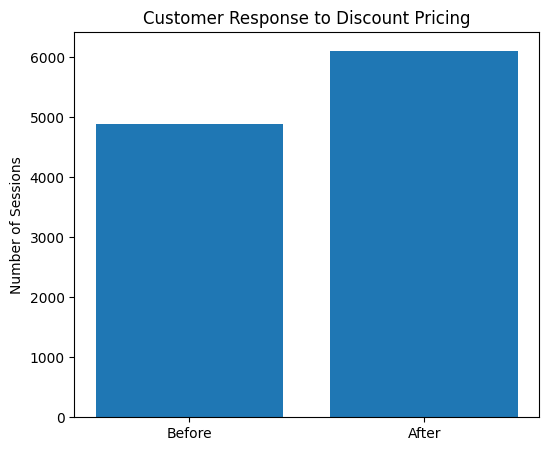

In [54]:
plt.figure(figsize=(6,5))

plt.bar(
    ['Before','After'],
    [before_sessions, after_sessions]
)

plt.title(
    'Customer Response to Discount Pricing'
)

plt.ylabel('Number of Sessions')

plt.show()

In [55]:
pricing_efficiency = (
    acn['dynamic_revenue'].sum()
    /
    acn['kWhDelivered'].sum()
)

print(
    "Pricing Efficiency Score:",
    pricing_efficiency
)

Pricing Efficiency Score: 15.435148718779983


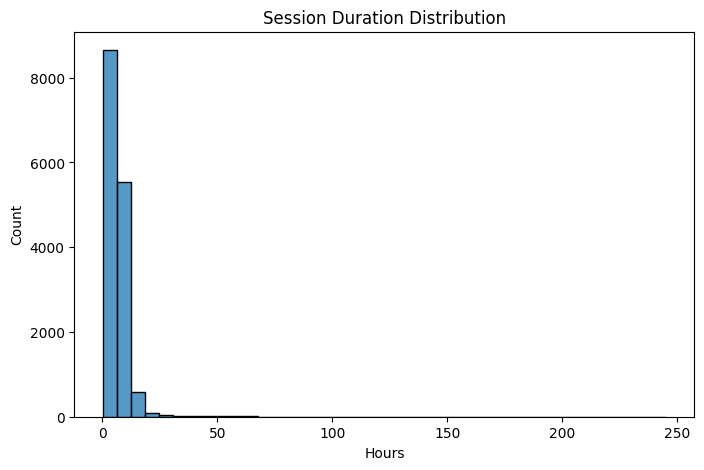

In [56]:
plt.figure(figsize=(8,5))

sns.histplot(
    acn['session_duration_hours'],
    bins=40
)

plt.title('Session Duration Distribution')

plt.xlabel('Hours')

plt.show()

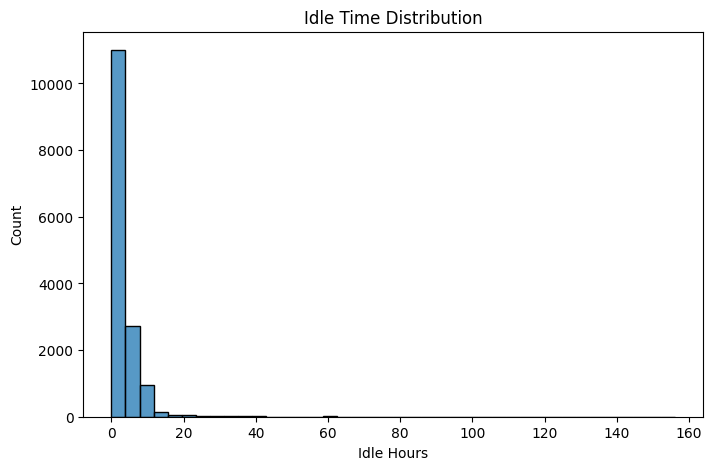

In [57]:
plt.figure(figsize=(8,5))

sns.histplot(
    acn['idle_time_hours'],
    bins=40
)

plt.title('Idle Time Distribution')

plt.xlabel('Idle Hours')

plt.show()

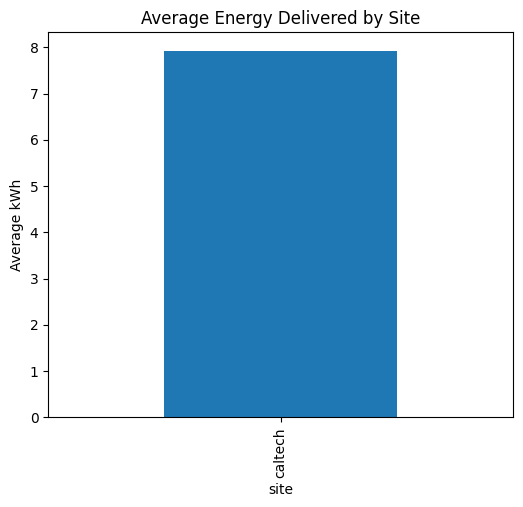

In [58]:
site_analysis = acn.groupby(
    'site'
)[
    'kWhDelivered'
].mean()

site_analysis.plot(
    kind='bar',
    figsize=(6,5)
)

plt.title('Average Energy Delivered by Site')

plt.ylabel('Average kWh')

plt.show()

In [59]:
acn.to_csv(
    'acn_behavioral_dataset.csv',
    index=False
)